# ⚙️ Notebook 2: Feature Engineering
### SupplyChain-AI-Agent | AIML Lab Assignment

**Input:** `Datasets/cleaned_data.csv`  
**Output:** `Datasets/processed_data.csv` + `Datasets/feature_cols.json`

**What we do here:**
- Create new meaningful features (delay gap, risk scores, date features)
- Encode categorical variables so ML models can use them
- Select final feature set — carefully excluding leaky columns

---

## 0. Imports & Setup

In [15]:
import pandas as pd           # pandas: for loading and manipulating the DataFrame
import numpy as np            # numpy: for numerical operations (e.g. np.where for safe division)
import matplotlib.pyplot as plt  # matplotlib: for all charts and subplots
import seaborn as sns         # seaborn: for nicer statistical visualisations
from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder: converts text categories to integers (e.g. 'Standard Class' → 0)
# StandardScaler: scales numbers to zero mean/unit variance — used later in NB3 for Logistic Regression
import warnings               # suppress non-critical runtime warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)  # consistent plot style
plt.rcParams['figure.figsize'] = (12, 4)  # default figure width × height in inches
plt.rcParams['figure.dpi'] = 100           # plot sharpness (dots per inch)

print('✅ Libraries loaded.')

✅ Libraries loaded.


## 1. Load Cleaned Data

In [16]:
# Load the cleaned CSV produced by Notebook 1
# encoding='latin-1' because the file was originally saved with that encoding
df = pd.read_csv('../Datasets/cleaned_data.csv', encoding='latin-1')

# The date columns are stored as strings in the CSV — convert them back to datetime
# so we can extract month, day-of-week etc. in the next section
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']
for col in date_cols:
    if col in df.columns:
        # errors='coerce' turns unparseable values into NaT instead of raising an error
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Confirm the data loaded correctly
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)   # preview first 3 rows

Loaded: 180,519 rows × 46 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance Shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,Complete,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late Delivery,1,73,Sporting Goods,Caguas,...,South Asia,RajastÃ¡n,Pending,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping On Time,0,73,Sporting Goods,San Jose,...,South Asia,RajastÃ¡n,Closed,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class


---
## 2. Feature Engineering
### 2.1 Core Delay Features

In [17]:
# ── delay_gap: how many days ahead or behind schedule was the delivery ─────
# Positive = late (real took longer than scheduled)
# Negative = early (arrived faster than scheduled)
# Zero     = exactly on time
df['delay_gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# ── is_late: simple binary flag derived from delay_gap ────────────────────
# (delay_gap > 0) produces True/False; .astype(int) converts to 1/0
df['is_late'] = (df['delay_gap'] > 0).astype(int)

# ── delay_severity: how many days late (0 if on time or early) ───────────
# clip(lower=0) replaces negative values (early deliveries) with 0
# so severity only measures actual lateness, not how early an order was
df['delay_severity'] = df['delay_gap'].clip(lower=0)

# Print summary statistics for the new delay_gap column
print('Delay gap statistics:')
print(df['delay_gap'].describe().round(2))

# Sanity check: is_late should match Late_delivery_risk almost perfectly
# If they match ~100% it confirms our delay_gap formula is correct
match_pct = (df['is_late'] == df['Late_delivery_risk']).mean() * 100
print(f"\n'is_late' matches 'Late_delivery_risk': {match_pct:.1f}%")

Delay gap statistics:
count    180519.00
mean          0.57
std           1.49
min          -2.00
25%           0.00
50%           1.00
75%           1.00
max           4.00
Name: delay_gap, dtype: float64

'is_late' matches 'Late_delivery_risk': 97.5%


### 2.2 Date-Based Features

In [18]:
# Extract calendar information from the order date
# These features help the model learn seasonal and weekly patterns in delays
order_col = 'order date (DateOrders)'

if order_col in df.columns:
    # .dt accessor lets us pull parts out of a datetime column
    df['order_month']     = df[order_col].dt.month         # 1=January, 12=December
    df['order_dayofweek'] = df[order_col].dt.dayofweek     # 0=Monday, 6=Sunday
    df['order_quarter']   = df[order_col].dt.quarter       # 1=Q1 (Jan-Mar), 4=Q4 (Oct-Dec)
    df['order_year']      = df[order_col].dt.year          # year of the order

    # is_weekend_order: 1 if the order was placed on Saturday (5) or Sunday (6)
    # Weekend orders may have less warehouse staffing and different delay patterns
    df['is_weekend_order'] = (df['order_dayofweek'] >= 5).astype(int)

    print('Date features created:')
    print(df[['order_month','order_dayofweek','order_quarter',
              'order_year','is_weekend_order']].head(4))

Date features created:
   order_month  order_dayofweek  order_quarter  order_year  is_weekend_order
0            1                2              1        2018                 0
1            1                5              1        2018                 1
2            1                5              1        2018                 1
3            1                5              1        2018                 1


### 2.3 Financial Derived Features

In [19]:
# ── profit_margin_ratio: profit as a fraction of sales ───────────────────
# np.where(condition, value_if_true, value_if_false) avoids division by zero:
# if Sales == 0, we set the ratio to 0 instead of getting infinity or NaN
df['profit_margin_ratio'] = np.where(
    df['Sales'] != 0,
    df['Order Profit Per Order'] / df['Sales'],   # profit fraction when Sales > 0
    0                                              # default to 0 when Sales = 0
).round(4)

# ── revenue_per_item: average price per unit in the order ─────────────────
# Again use np.where to safely handle orders with zero quantity
df['revenue_per_item'] = np.where(
    df['Order Item Quantity'] != 0,
    df['Sales'] / df['Order Item Quantity'],   # revenue per unit
    0
).round(2)

# ── high_discount_flag: 1 if discount rate exceeds 10% ───────────────────
# Heavy discounting can signal demand problems or urgent clearance
# which may correlate with different shipping urgency
df['high_discount_flag'] = (df['Order Item Discount Rate'] > 0.10).astype(int)

# ── high_value_order: 1 if this order's sales are above the overall median ─
# High-value orders may be handled differently (priority shipping, more care)
sales_median = df['Sales'].median()  # compute median once, reuse for all rows
df['high_value_order'] = (df['Sales'] > sales_median).astype(int)

print(f"Sales median threshold for 'high_value_order': {sales_median:.2f}")
print(df[['profit_margin_ratio','revenue_per_item',
           'high_discount_flag','high_value_order']].describe().round(3))

Sales median threshold for 'high_value_order': 199.92
       profit_margin_ratio  revenue_per_item  high_discount_flag  \
count           180519.000        180519.000            180519.0   
mean                 0.112           138.620                 0.5   
std                  0.400           122.091                 0.5   
min                 -2.750             9.990                 0.0   
25%                  0.062            50.000                 0.0   
50%                  0.241            59.990                 1.0   
75%                  0.336           199.990                 1.0   
max                  0.500           499.950                 1.0   

       high_value_order  
count        180519.000  
mean              0.488  
std               0.500  
min               0.000  
25%               0.000  
50%               0.000  
75%               1.000  
max               1.000  


### 2.4 Historical Risk Scores (Shipping Mode & Market)

In [20]:
# ── shipping_mode_risk: historical late rate per shipping mode ────────────
# groupby('Shipping Mode') splits data into groups (Standard Class, First Class, etc.)
# .mean() on the binary Late_delivery_risk column = fraction of orders that were late
# This is a 'target encoding' — it encodes category by its historical outcome rate
ship_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean()
print('Late delivery rate by Shipping Mode:')
print(ship_risk.sort_values(ascending=False).round(3))

# .map(ship_risk) replaces each Shipping Mode string with its late rate number
# e.g. 'Standard Class' → 0.60 (if 60% of Standard Class orders are late)
df['shipping_mode_risk'] = df['Shipping Mode'].map(ship_risk).round(3)
print("\n'shipping_mode_risk' column added.")

Late delivery rate by Shipping Mode:
Shipping Mode
First Class       0.953
Second Class      0.766
Same Day          0.457
Standard Class    0.381
Name: Late_delivery_risk, dtype: float64

'shipping_mode_risk' column added.


In [21]:
# ── market_risk_score: historical late rate per geographic market ─────────
# Markets: LATAM, Europe, Pacific Asia, USCA, Africa
# Each market may have very different logistics infrastructure and delay rates
region_risk = df.groupby('Market')['Late_delivery_risk'].mean()
print('Late delivery rate by Market:')
print(region_risk.sort_values(ascending=False).round(3))

# Map each row's Market value to its historical late rate
df['market_risk_score'] = df['Market'].map(region_risk).round(3)
print("\n'market_risk_score' column added.")

Late delivery rate by Market:
Market
Europe          0.552
Pacific Asia    0.550
Usca            0.548
Africa          0.546
Latam           0.544
Name: Late_delivery_risk, dtype: float64

'market_risk_score' column added.


### 2.5 Category, Department & Segment Risk Rates

In [22]:
# ── category_late_rate: historical late rate per product category ─────────
# Some product categories (e.g. electronics) may have stricter shipping requirements
# and different delay patterns compared to other categories
cat_risk = df.groupby('Category Name')['Late_delivery_risk'].mean()
df['category_late_rate'] = df['Category Name'].map(cat_risk).round(3)
print("'category_late_rate' added. Sample:")
print(df[['Category Name','category_late_rate']].drop_duplicates().head(8).to_string(index=False))

'category_late_rate' added. Sample:
   Category Name  category_late_rate
  Sporting Goods               0.555
          Cleats               0.550
   Shop By Sport               0.552
 Women'S Apparel               0.546
     Electronics               0.561
    Boxing & Mma               0.563
Cardio Equipment               0.545
        Trade-In               0.556


In [23]:
# ── dept_late_rate: historical late rate per department ──────────────────
# Departments group related categories (e.g. 'Fan Shop', 'Apparel')
# Some departments may use different warehouses or suppliers → different delay rates
dept_risk = df.groupby('Department Name')['Late_delivery_risk'].mean()
df['dept_late_rate'] = df['Department Name'].map(dept_risk).round(3)
print("'dept_late_rate' added.")

# ── segment_late_rate: historical late rate per customer segment ───────────
# Segments: Consumer, Corporate, Home Office
# Corporate customers may have SLAs that affect how orders are prioritised
seg_risk = df.groupby('Customer Segment')['Late_delivery_risk'].mean()
df['segment_late_rate'] = df['Customer Segment'].map(seg_risk).round(3)
print("'segment_late_rate' added.")

# ── scheduled_days_bin: bucket the scheduled shipping days into 4 groups ──
# The model learns cleaner decision boundaries from discrete bins
# rather than a single integer (0, 2, 4, 6 → bins 0, 1, 2, 3)
df['scheduled_days_bin'] = pd.cut(
    df['Days for shipment (scheduled)'],
    bins=[0, 2, 4, 6, 100],   # boundaries: 0–2=bin0, 2–4=bin1, 4–6=bin2, 6+=bin3
    labels=[0, 1, 2, 3]       # integer labels for each bin
)
# Any value that fell outside the bins becomes NaN → fill with -1 then convert to int
df['scheduled_days_bin'] = df['scheduled_days_bin'].cat.add_categories([-1]).fillna(-1).astype(int)
print("'scheduled_days_bin' added.")

# ── ship_mode_x_sched: interaction feature ────────────────────────────────
# Multiplying shipping_mode_risk × scheduled days captures the combined effect:
# a high-risk shipping mode on a long schedule is especially likely to be late
df['ship_mode_x_sched'] = df['shipping_mode_risk'] * df['Days for shipment (scheduled)']
print("'ship_mode_x_sched' interaction feature added.")

print('\n✅ Additional features engineered successfully.')

'dept_late_rate' added.
'segment_late_rate' added.
'scheduled_days_bin' added.
'ship_mode_x_sched' interaction feature added.

✅ Additional features engineered successfully.


## 3. Feature Visualizations

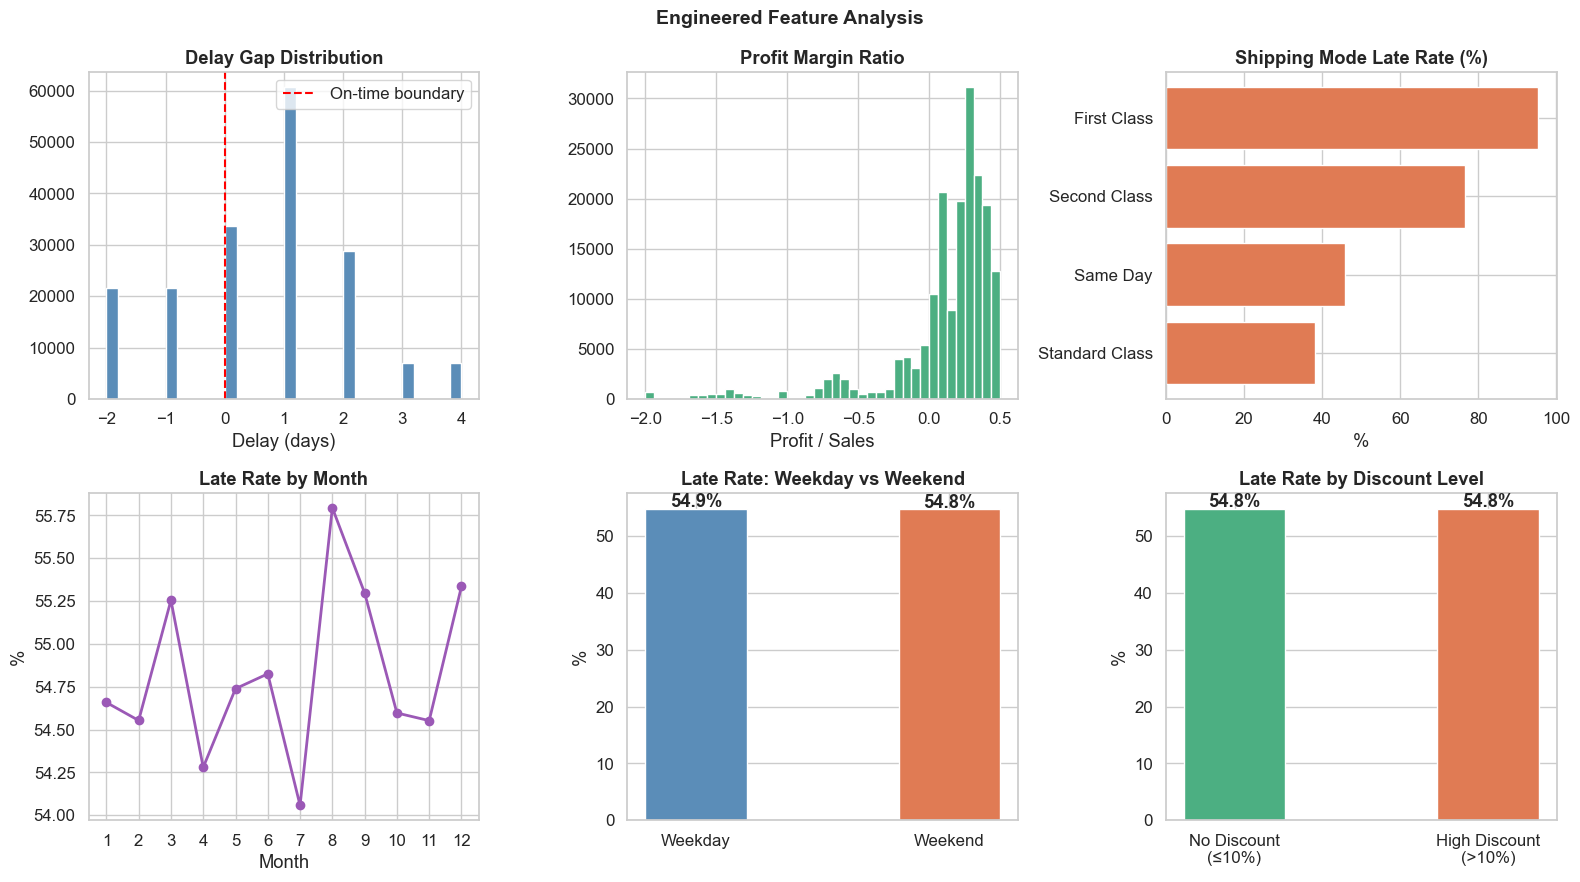

In [24]:
# Plot 6 charts in a 2×3 grid to explore the new engineered features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── Chart 1: delay_gap distribution ──────────────────────────────────────
# Shows how orders spread around the on-time boundary (0)
axes[0,0].hist(df['delay_gap'], bins=30, color='#5B8DB8', edgecolor='white')
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='On-time boundary')
axes[0,0].set_title('Delay Gap Distribution', fontweight='bold')
axes[0,0].set_xlabel('Delay (days)')
axes[0,0].legend()

# ── Chart 2: profit_margin_ratio distribution ─────────────────────────────
# clip(-2, 2) removes extreme outliers for a cleaner histogram shape
axes[0,1].hist(df['profit_margin_ratio'].clip(-2, 2), bins=40,
               color='#4CAF82', edgecolor='white')
axes[0,1].set_title('Profit Margin Ratio', fontweight='bold')
axes[0,1].set_xlabel('Profit / Sales')

# ── Chart 3: late rate by shipping mode ──────────────────────────────────
# Shows which shipping modes tend to have the most delays
ship_risk_sorted = ship_risk.sort_values()
axes[0,2].barh(ship_risk_sorted.index, ship_risk_sorted.values * 100,
               color='#E07B54')
axes[0,2].set_title('Shipping Mode Late Rate (%)', fontweight='bold')
axes[0,2].set_xlabel('%')

# ── Chart 4: late rate by calendar month ─────────────────────────────────
# Helps detect seasonal patterns — e.g. holiday months may have more delays
month_late = df.groupby('order_month')['Late_delivery_risk'].mean() * 100
axes[1,0].plot(month_late.index, month_late.values, marker='o',
               color='#9B59B6', linewidth=2)
axes[1,0].set_title('Late Rate by Month', fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('%')
axes[1,0].set_xticks(range(1, 13))  # show all 12 months on x-axis

# ── Chart 5: weekday vs weekend late rate ─────────────────────────────────
# Compares if orders placed on weekends have different delay rates
weekend_late = df.groupby('is_weekend_order')['Late_delivery_risk'].mean() * 100
axes[1,1].bar(['Weekday', 'Weekend'], weekend_late.values,
              color=['#5B8DB8', '#E07B54'], width=0.4)
axes[1,1].set_title('Late Rate: Weekday vs Weekend', fontweight='bold')
axes[1,1].set_ylabel('%')
for i, v in enumerate(weekend_late.values):
    axes[1,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Chart 6: discount level vs late rate ─────────────────────────────────
# Does offering a high discount affect shipping delay rate?
disc_late = df.groupby('high_discount_flag')['Late_delivery_risk'].mean() * 100
axes[1,2].bar(['No Discount\n(≤10%)', 'High Discount\n(>10%)'],
              disc_late.values, color=['#4CAF82', '#E07B54'], width=0.4)
axes[1,2].set_title('Late Rate by Discount Level', fontweight='bold')
axes[1,2].set_ylabel('%')
for i, v in enumerate(disc_late.values):
    axes[1,2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Engineered Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Encode Categorical Columns

In [25]:
# ML models cannot process text strings directly — we must convert them to numbers
# LabelEncoder assigns a unique integer to each unique category value
# e.g. ['Standard Class', 'First Class', 'Same Day'] → [2, 0, 1]
# Note: the mapping is arbitrary — tree-based models handle this fine

# Columns to encode — these are key categorical attributes for the model
cat_to_encode = [
    'Shipping Mode',      # Standard Class, First Class, Second Class, Same Day
    'Market',             # LATAM, Europe, Pacific Asia, USCA, Africa
    'Customer Segment',   # Consumer, Corporate, Home Office
    'Department Name',    # Fan Shop, Apparel, Golf, etc.
    'Category Name',      # Cleats, Men's Footwear, Women's Apparel, etc.
    'Order Status',       # COMPLETE, PENDING_PAYMENT, PROCESSING, etc.
]
# Only encode columns that actually exist after cleaning
cat_to_encode = [c for c in cat_to_encode if c in df.columns]

le = LabelEncoder()   # create one LabelEncoder instance; we reuse it for each column

for col in cat_to_encode:
    # Build the encoded column name by lowercasing and adding '_enc'
    # e.g. 'Shipping Mode' → 'shipping_mode_enc'
    encoded_col = col.lower().replace(' ', '_') + '_enc'

    # fit_transform: learn all unique values (fit) then convert them to integers (transform)
    # .astype(str) ensures any accidental non-string values don't cause errors
    df[encoded_col] = le.fit_transform(df[col].astype(str))

    print(f"  '{col}' → '{encoded_col}'  ({df[col].nunique()} classes)")

print('\n✅ Encoding complete.')

  'Shipping Mode' → 'shipping_mode_enc'  (4 classes)
  'Market' → 'market_enc'  (5 classes)
  'Customer Segment' → 'customer_segment_enc'  (3 classes)
  'Department Name' → 'department_name_enc'  (11 classes)
  'Category Name' → 'category_name_enc'  (50 classes)
  'Order Status' → 'order_status_enc'  (9 classes)

✅ Encoding complete.


## 5. Select Final Feature Set

In [26]:
# ── IMPORTANT: Why we exclude delay_gap and Days for shipping (real) ─────
# delay_gap = Days_real − Days_scheduled — this directly contains the answer
# Days for shipping (real) is only known AFTER the shipment, not at order time
# Including them would be DATA LEAKAGE: the model would learn to predict using
# information it cannot possibly have when making a real-time prediction
# A real agent only knows scheduled days, not actual shipping days

FEATURE_COLS = [
    # ── Shipping & time features (all known at order placement) ──────────
    'Days for shipment (scheduled)',   # how many days the system promises for shipping
    'scheduled_days_bin',              # binned version — helps model learn discrete thresholds
    'order_month',                     # month of order — captures seasonal patterns
    'order_dayofweek',                 # day of week — weekends may differ from weekdays
    'order_quarter',                   # quarter — Q4 holidays often cause more delays
    'is_weekend_order',                # binary flag for weekend-placed orders
    # ── Financial features ───────────────────────────────────────────────
    'Sales',                           # total revenue for the order
    'Order Profit Per Order',          # profit — loss orders may be deprioritised
    'Order Item Quantity',             # number of items — larger orders may take longer
    'Order Item Discount Rate',        # raw discount percentage
    'profit_margin_ratio',             # profit as fraction of sales
    'revenue_per_item',                # average price per unit
    'high_discount_flag',              # 1 if discount > 10%
    'high_value_order',                # 1 if sales > median
    # ── Historical risk scores (target-encoded, no leakage) ───────────
    'shipping_mode_risk',              # historical late rate for this shipping mode
    'market_risk_score',               # historical late rate for this market
    'category_late_rate',              # historical late rate for this product category
    'dept_late_rate',                  # historical late rate for this department
    'segment_late_rate',               # historical late rate for this customer segment
    # ── Interaction feature ──────────────────────────────────────────────
    'ship_mode_x_sched',               # shipping_mode_risk × scheduled days
    # ── Encoded categorical columns ──────────────────────────────────────
    'shipping_mode_enc',               # integer-encoded Shipping Mode
    'market_enc',                      # integer-encoded Market
    'customer_segment_enc',            # integer-encoded Customer Segment
    'department_name_enc',             # integer-encoded Department Name
    'category_name_enc',               # integer-encoded Category Name
    'order_status_enc',                # integer-encoded Order Status
]

# Target: what the model must predict (1 = late, 0 = on time)
TARGET_COL = 'Late_delivery_risk'

# Keep only feature columns that actually exist in the DataFrame
# (safety check in case any engineering step was skipped)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f'Final feature count: {len(FEATURE_COLS)}')
print(FEATURE_COLS)
print('\n✅ Leaky features (delay_gap, delay_severity, Days for shipping real) excluded.')

Final feature count: 26
['Days for shipment (scheduled)', 'scheduled_days_bin', 'order_month', 'order_dayofweek', 'order_quarter', 'is_weekend_order', 'Sales', 'Order Profit Per Order', 'Order Item Quantity', 'Order Item Discount Rate', 'profit_margin_ratio', 'revenue_per_item', 'high_discount_flag', 'high_value_order', 'shipping_mode_risk', 'market_risk_score', 'category_late_rate', 'dept_late_rate', 'segment_late_rate', 'ship_mode_x_sched', 'shipping_mode_enc', 'market_enc', 'customer_segment_enc', 'department_name_enc', 'category_name_enc', 'order_status_enc']

✅ Leaky features (delay_gap, delay_severity, Days for shipping real) excluded.


## 5. Feature Correlation with Target

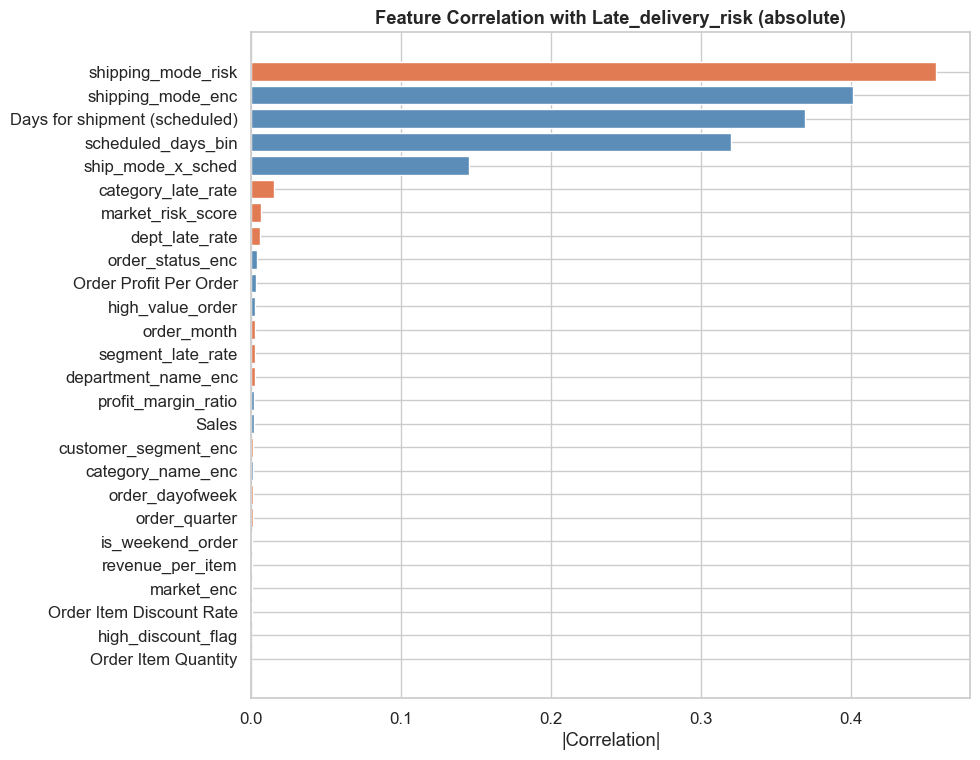

In [27]:
# Compute Pearson correlation of each feature with the target column
# .corr() computes all pairwise correlations; we select just the target column
# .drop(TARGET_COL) removes the target's correlation with itself (which is always 1.0)
corr_with_target = df[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)

# Sort by absolute correlation — strongest predictors at the bottom (highest in chart)
corr_sorted = corr_with_target.abs().sort_values(ascending=True)

# Size the chart based on how many features there are (so bars don't get squished)
fig, ax = plt.subplots(figsize=(10, max(6, len(corr_sorted)*0.3)))

# Color positive correlations orange, negative correlations blue
colors = ['#E07B54' if v > 0 else '#5B8DB8'
          for v in corr_with_target[corr_sorted.index].values]

# Horizontal bar chart — easier to read feature names on y-axis
ax.barh(corr_sorted.index, corr_sorted.values, color=colors)
ax.set_title('Feature Correlation with Late_delivery_risk (absolute)',
             fontweight='bold')
ax.set_xlabel('|Correlation|')   # absolute value so direction doesn't matter here
plt.tight_layout()
plt.show()

## 6. Save Processed Data

In [28]:
# Keep only: Order Id (for traceability) + 26 features + 1 target column
# 'Order Id' lets us trace any prediction back to a real order later
id_cols = ['Order Id'] if 'Order Id' in df.columns else []

# Slice the DataFrame to only the columns we need
processed_df = df[id_cols + FEATURE_COLS + [TARGET_COL]].copy()

# Save the processed DataFrame as a CSV for Notebook 3 to read
# index=False prevents the row number from being written as a column
processed_df.to_csv('../Datasets/processed_data.csv', index=False)

# Save the feature column list as a JSON file so Notebook 3 uses exactly the same features
# This avoids any manual copy-pasting of the feature list between notebooks
import json
with open('../Datasets/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)   # json.dump writes the Python list as JSON

print(f'✅ Saved processed_data.csv  →  {processed_df.shape[0]:,} rows × {processed_df.shape[1]} cols')
print(f'✅ Saved feature_cols.json')
print('\n→ Next step: Run Notebook 3 — Delay Prediction Model')

✅ Saved processed_data.csv  →  180,519 rows × 28 cols
✅ Saved feature_cols.json

→ Next step: Run Notebook 3 — Delay Prediction Model
